In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

## LOAD PIPELINE

In [6]:
import torch
from diffusers import StableDiffusion3Pipeline

DEVICE = "cuda"
DTYPE = torch.float16
MODEL_ID = "stabilityai/stable-diffusion-3-medium-diffusers"

pipe = StableDiffusion3Pipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
).to(DEVICE)

Loading pipeline components...: 100%|██████████| 9/9 [00:02<00:00,  4.11it/s]


## Capture

In [7]:
'''
captured
├── 0  (step)
│   ├── 0  (block) → {L_minus_1, L_after_attn, L_output}
│   ├── 1  → {...}
│   └── ...
├── 1
│   └── ...
'''

'\ncaptured\n├── 0  (step)\n│   ├── 0  (block) → {L_minus_1, L_after_attn, L_output}\n│   ├── 1  → {...}\n│   └── ...\n├── 1\n│   └── ...\n'

In [8]:
import sys, torch
sys.path.insert(0, "../mode_path")

from sd3_hook import patch_transformer, attach_step_tracker

# ── 설정 ──
PROMPTS = [
    "a cat",
    "raining night city",
    "ancient rusty robot",
    "library",
    "A majestic queen whose dress is made of thousands of living butterflies and wildflowers, standing in a field of lavender at sunset, ethereal glow, soft bokeh background.",
    "A transparent glass apple with a miniature forest growing inside.",
    "Astronaut drinking coffee on the moon, Earth in background.",
    "Flying Man",
    "Singing Bird in the beach",
    "fish with big mouth",
]
SEEDS = [42, 7, 123, 2024, 99, 314, 1618, 555, 8888, 31337]   # prompt별 고정 seed

NUM_STEPS      = 28
GUIDANCE_SCALE = 7.0

# ── step tracker ──
step_counter = attach_step_tracker(pipe.transformer, on_step=lambda s: True)
if step_counter is None:
    raise RuntimeError("step tracker 이미 부착됨. 커널 재시작 후 다시 실행하세요.")

# ── 저장소: results[prompt_idx][step][block] ──
results = {}
images  = {}
_current_pidx = {"v": None}

def on_capture(block_idx, L_minus_1, L_after_attn, L_output, batch_size):
    p_idx = _current_pidx["v"]
    if p_idx is None:
        return
    step_idx = step_counter[0]
    cap = results[p_idx]
    cap.setdefault(step_idx, {})[block_idx] = {
        "L_minus_1":    L_minus_1.float(),
        "L_after_attn": L_after_attn.float(),
        "L_output":     L_output.float(),
    }

patch_transformer(pipe.transformer, on_capture)

# ── 메인 루프 ──
for p_idx, (prompt, seed) in enumerate(zip(PROMPTS, SEEDS)):
    results[p_idx] = {}
    _current_pidx["v"] = p_idx
    step_counter[0] = 0

    generator = torch.Generator(device=pipe.device).manual_seed(seed)
    images[p_idx] = pipe(
        prompt,
        num_inference_steps=NUM_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=generator,
    ).images[0]

    print(f"[p{p_idx:02d} seed={seed}] steps={len(results[p_idx])}, blocks={len(results[p_idx][0])}  | {prompt[:50]}")

_current_pidx["v"] = None
print(f"done. {len(results)} prompts captured.")


100%|██████████| 28/28 [00:42<00:00,  1.52s/it]


[p00 seed=42] steps=28, blocks=24  | a cat


100%|██████████| 28/28 [00:42<00:00,  1.51s/it]


[p01 seed=7] steps=28, blocks=24  | raining night city


100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


...

[p07 seed=555] steps=28, blocks=24  | Flying Man


100%|██████████| 28/28 [00:50<00:00,  1.80s/it]


[p08 seed=8888] steps=28, blocks=24  | Singing Bird in the beach


100%|██████████| 28/28 [00:49<00:00,  1.78s/it]

[p09 seed=31337] steps=28, blocks=24  | fish with big mouth
done. 10 prompts captured.


In [10]:
print(len(results))
print(len(results[0]))
print(len(results[0][0]))

10
28
24


## Component num

### 마지막 step, 마지막 블록

#### 최대 SV 기준

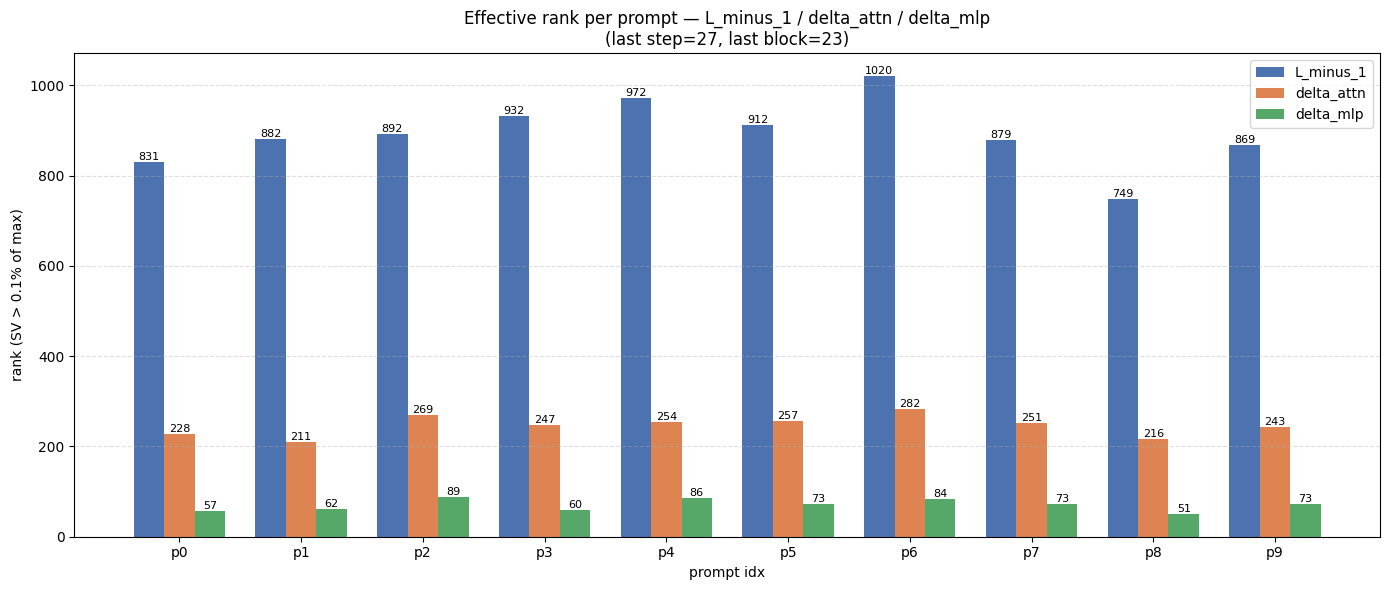

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── 설정 ──
last_step  = max(results[0].keys())
last_block = max(results[0][last_step].keys())
COMPONENTS = ["L_minus_1", "delta_attn", "delta_mlp"]
THRESHOLD_RATIO = 5e-3   # 1%

# ── rank 계산 ──
rank_dict = {k: [] for k in COMPONENTS}
for p_idx in sorted(results.keys()):
    d = results[p_idx][last_step][last_block]

    # CFG cond branch (batch index 1)
    L_minus_1    = d["L_minus_1"][1]
    L_after_attn = d["L_after_attn"][1]
    L_output     = d["L_output"][1]

    tensors = {
        "L_minus_1":  L_minus_1,                       # block 입력
        "delta_attn": L_after_attn - L_minus_1,        # attention 기여
        "delta_mlp":  L_output     - L_after_attn,     # MLP 기여
    }
    for key, t in tensors.items():
        sv = torch.linalg.svdvals(t)
        rank = int((sv > THRESHOLD_RATIO * sv.max()).sum().item())
        rank_dict[key].append(rank)

# ── grouped bar chart ──
n_prompts = len(PROMPTS)
x = np.arange(n_prompts)
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, key in enumerate(COMPONENTS):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, rank_dict[key], width, label=key, color=colors[i])
    for b, v in zip(bars, rank_dict[key]):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v),
                ha="center", va="bottom", fontsize=8)

ax.set_xlabel("prompt idx")
ax.set_ylabel("rank (SV > 0.1% of max)")
ax.set_title(f"Effective rank per prompt — L_minus_1 / delta_attn / delta_mlp\n"
             f"(last step={last_step}, last block={last_block})")
ax.set_xticks(x)
ax.set_xticklabels([f"p{i}" for i in range(n_prompts)])
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


#### 분산 기준

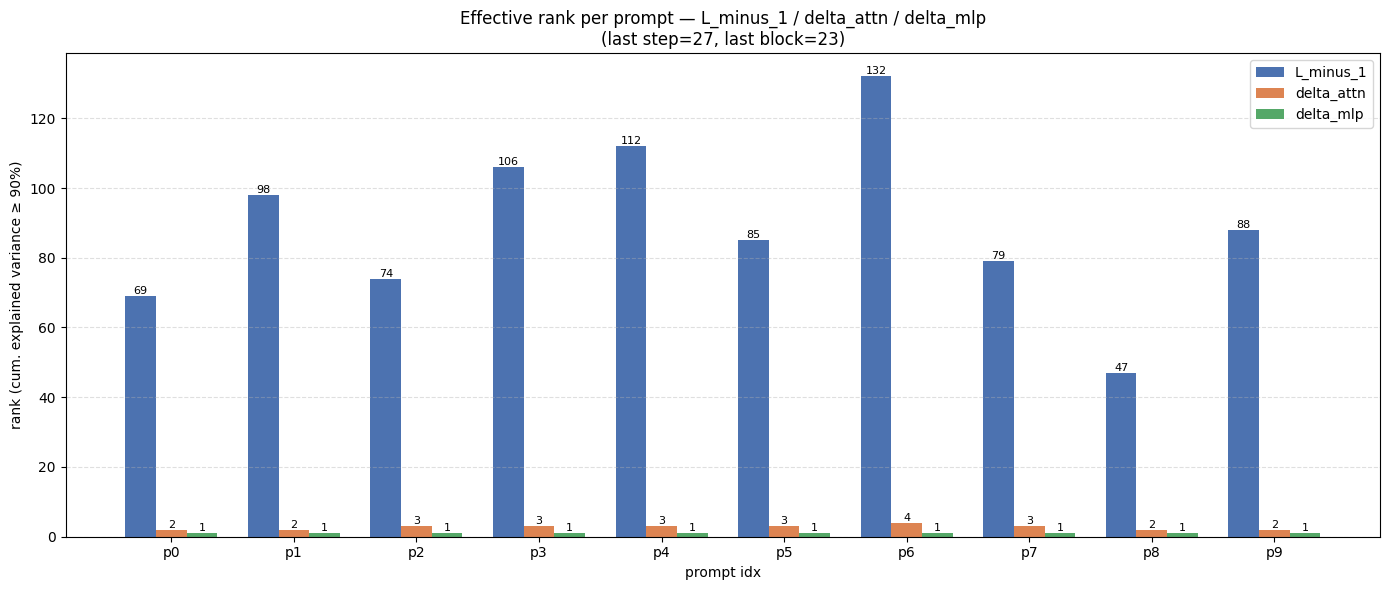

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── 설정 ──
last_step  = max(results[0].keys())
last_block = max(results[0][last_step].keys())
COMPONENTS = ["L_minus_1", "delta_attn", "delta_mlp"]
EV_THRESHOLD = 0.90   # 누적 explained variance 90%

# ── rank 계산 (cumulative explained variance ≥ 90%) ──
rank_dict = {k: [] for k in COMPONENTS}
for p_idx in sorted(results.keys()):
    d = results[p_idx][last_step][last_block]

    # CFG cond branch
    L_minus_1    = d["L_minus_1"][1]
    L_after_attn = d["L_after_attn"][1]
    L_output     = d["L_output"][1]

    tensors = {
        "L_minus_1":  L_minus_1,
        "delta_attn": L_after_attn - L_minus_1,
        "delta_mlp":  L_output     - L_after_attn,
    }
    for key, t in tensors.items():
        sv = torch.linalg.svdvals(t)             # (min(M,N),)
        energy = sv ** 2                          # variance ∝ sv^2
        cum = torch.cumsum(energy, dim=0) / energy.sum()
        rank = int((cum < EV_THRESHOLD).sum().item()) + 1
        rank_dict[key].append(rank)

# ── grouped bar chart ──
n_prompts = len(PROMPTS)
x = np.arange(n_prompts)
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, key in enumerate(COMPONENTS):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, rank_dict[key], width, label=key, color=colors[i])
    for b, v in zip(bars, rank_dict[key]):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v),
                ha="center", va="bottom", fontsize=8)

ax.set_xlabel("prompt idx")
ax.set_ylabel(f"rank (cum. explained variance ≥ {int(EV_THRESHOLD*100)}%)")
ax.set_title(f"Effective rank per prompt — L_minus_1 / delta_attn / delta_mlp\n"
             f"(last step={last_step}, last block={last_block})")
ax.set_xticks(x)
ax.set_xticklabels([f"p{i}" for i in range(n_prompts)])
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### 모든 블록과 스텝

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt

EV_THRESHOLD = 0.90
COMPONENTS = ["delta_attn", "delta_mlp"]

n_steps  = max(results[0].keys()) + 1
n_blocks = max(results[0][0].keys()) + 1
n_prompts = len(results)

# rank_grid[component] = (n_prompts, n_steps, n_blocks)
rank_grid = {k: np.zeros((n_prompts, n_steps, n_blocks), dtype=np.int32) for k in COMPONENTS}

for p in sorted(results.keys()):
    for s in range(n_steps):
        for b in range(n_blocks):
            d = results[p][s][b]
            L_m1   = d["L_minus_1"][1]
            L_attn = d["L_after_attn"][1]
            L_out  = d["L_output"][1]
            tensors = {
                "delta_attn": L_attn - L_m1,
                "delta_mlp":  L_out  - L_attn,
            }
            for k, t in tensors.items():
                sv = torch.linalg.svdvals(t)
                cum = torch.cumsum(sv**2, dim=0) / (sv**2).sum()
                rank_grid[k][p, s, b] = int((cum < EV_THRESHOLD).sum().item()) + 1

# prompt 평균 heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, k in zip(axes, COMPONENTS):
    mean_grid = rank_grid[k].mean(axis=0)   # (n_steps, n_blocks)
    im = ax.imshow(mean_grid, aspect="auto", cmap="viridis", origin="lower")
    ax.set_xlabel("block idx")
    ax.set_ylabel("step idx")
    ax.set_title(f"{k} — effective rank (avg over {n_prompts} prompts)")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
